<a href="https://colab.research.google.com/github/jadiarmtz/extract-angular-coeficents-/blob/main/copia_de_mlm_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install Optuna for hyperparameter optimization if not already installed
!pip install optuna

In [ ]:
# *** Se importan las bibliotecas necesarias para:
# 1) Manipulación de datos (pandas, numpy)
# 2) Machine Learning (scikit-learn)
# 3) Visualización de datos (matplotlib, seaborn) ***
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import math # Added for CalSig function

# Cargar los datos. Asumiendo que el nuevo DataFrame se llama 'higgs_analysis_features.csv'
data = pd.read_csv('dataframe500k.csv')

# Impresión de información de la base de datos
print('Size of data: {}'.format(data.shape))

Size of data: (15882, 25)


In [ ]:
# Impresión de información de la base de datos
print('Size of data: {}'.format(data.shape))
print('Number of events: {}'.format(data.shape[0]))
print('Number of columns: {}'.format(data.shape[1]))

print('\nList of features in dataset:')
for col in data.columns:
    print(col)

Size of data: (15882, 25)
Number of events: 15882
Number of columns: 25

List of features in dataset:
DER_mass_cons
DER_mass_corr
DER_mass_vis
mtt_vis
PRI_tau1_pt
PRI_tau1_eta
PRI_tau1_phi
PRI_tau2_pt
PRI_tau2_eta
PRI_tau2_phi
PRI_Z_pt
PRI_Z_eta
PRI_Z_phi
PRI_Z_mass
PRI_met
PRI_met_phi
PRI_njets
DER_deltaR_tau_tau
DER_deltaR_Z_tau1
DER_deltaR_Z_tau2
DER_pt_A
DER_sum_pt
Label
weight
process


In [ ]:
# Impresión del número de eventos y fracción de la señal
# La columna 'Label' ahora contiene 1 para señal y 0 para background
print('Number of signal events: {}'.format(len(data[data.Label == 1])))
print('Number of background events: {}'.format(len(data[data.Label == 0])))
print('Fraction signal: {}'.format(len(data[data.Label == 1])/(float)(len(data[data.Label == 1]) + len(data[data.Label == 0]))))

Number of signal events: 7785
Number of background events: 8097
Fraction signal: 0.49017755950132225


In [ ]:
print(data)

# Especificar el número de eventos señal y background
# Ajusta estos valores si tu dataset 'higgs_analysis_features.csv' es más pequeño
n_signal = 300000
n_background = 300000

# Se definen los eventos de background (Label=0) y señal (Label=1)
s_events = data[data['Label'] == 1].head(n_signal) # Eventos señal
b_events = data[data['Label'] == 0].head(n_background) # Eventos background

# Combinando bases de datos para el entrenamiento
data_unido = pd.concat([s_events, b_events], ignore_index=True) # Unir señal y background

# Actualizar base de datos a la unida
data = data_unido

       DER_mass_cons  DER_mass_corr  DER_mass_vis     mtt_vis  PRI_tau1_pt  \
0         344.160625     387.498865     341.85760  122.175594    95.480470   
1         330.126399     353.801547     299.94437  103.449716   126.309030   
2         340.482597     296.378515     254.80330   70.110632    69.456870   
3         320.619218     309.946430     282.63892   96.555884    91.316696   
4         346.581035     383.845384     344.31160  123.456501   110.219260   
...              ...            ...           ...         ...          ...   
15877     433.694284     524.819938     464.45550  141.992409   113.689285   
15878     396.789474     398.957813     359.11417  102.585056   100.931230   
15879     291.978805     310.706941     273.06616  109.197135    62.747635   
15880     330.444926     312.813917     280.91824   90.206831    58.012047   
15881     233.326529     307.712294     263.20282  150.339433    96.971580   

       PRI_tau1_eta  PRI_tau1_phi  PRI_tau2_pt  PRI_tau2_eta  P

In [ ]:
# Elección de la señal y background
sig_df = data[data.Label == 1]
bkg_df = data[data.Label == 0]

In [ ]:
# Definir las variables para el entrenamiento
# Excluir 'Label', 'weight' y 'process' de las características
vars_for_train = [col for col in data.columns if col not in ['Label', 'weight', 'process']]

signal4train = sig_df[vars_for_train]
bkg4train = bkg_df[vars_for_train]

# Las variables para el entrenamiento ahora están en vars_for_train
print("Variables para el entrenamiento:", vars_for_train)

Variables para el entrenamiento: ['DER_mass_cons', 'DER_mass_corr', 'DER_mass_vis', 'mtt_vis', 'PRI_tau1_pt', 'PRI_tau1_eta', 'PRI_tau1_phi', 'PRI_tau2_pt', 'PRI_tau2_eta', 'PRI_tau2_phi', 'PRI_Z_pt', 'PRI_Z_eta', 'PRI_Z_phi', 'PRI_Z_mass', 'PRI_met', 'PRI_met_phi', 'PRI_njets', 'DER_deltaR_tau_tau', 'DER_deltaR_Z_tau1', 'DER_deltaR_Z_tau2', 'DER_pt_A', 'DER_sum_pt']


In [ ]:
print(f"Bkg size: {len(bkg4train.index)}")
print(f"Signal size: {len(signal4train.index)}")

Bkg size: 8097
Signal size: 7785


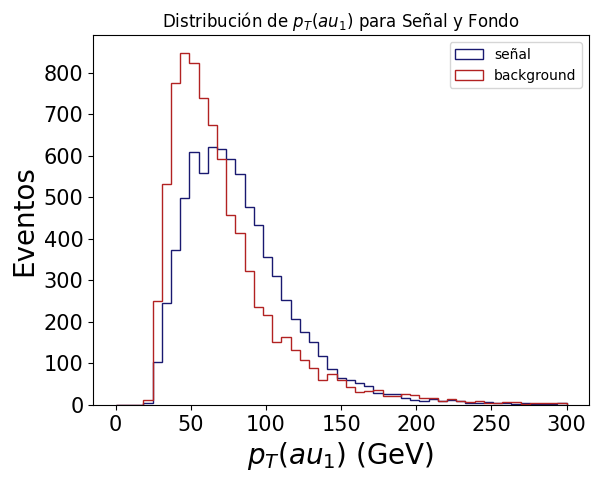


Observación: La distribución de PRI_tau1_pt muestra diferencias entre la señal y el fondo, lo cual puede ser útil para la clasificación.


In [ ]:
# Distribución de PRI_tau1_pt para Señal y Fondo
plt.figure();
plt.hist(data.PRI_tau1_pt[data.Label == 1], bins=np.linspace(0, 300, 50), # Adjust bins as needed for PRI_tau1_pt range
         histtype='step', color='midnightblue', label='señal', alpha=1);
plt.hist(data.PRI_tau1_pt[data.Label == 0], bins=np.linspace(0, 300, 50), # Adjust bins as needed
         histtype='step', color='firebrick', label='background', alpha=1);
plt.xlabel('$p_{T}(\tau_{1})$ (GeV)', fontsize=20); # Updated label for PRI_tau1_pt
plt.ylabel('Eventos', fontsize=20);
plt.legend(frameon=True);
plt.xticks(fontsize=15);
plt.yticks(fontsize=15);
plt.title('Distribución de $p_{T}(\tau_{1})$ para Señal y Fondo'); # Added title
plt.show()
print("\nObservación: La distribución de PRI_tau1_pt muestra diferencias entre la señal y el fondo, lo cual puede ser útil para la clasificación.")

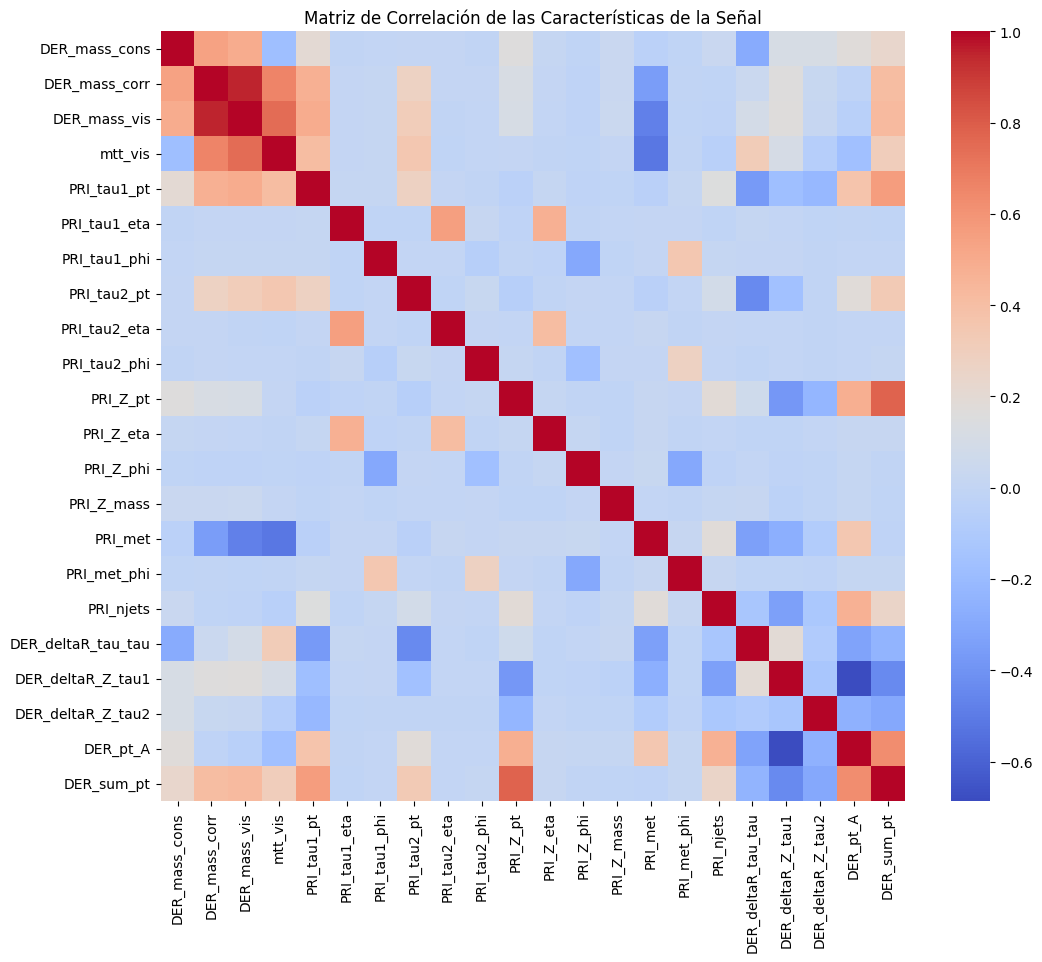


Observación: La matriz de correlación muestra las relaciones entre las características de la señal. Se identificaron algunas características con alta correlación.


In [ ]:
# Correlaciones
correlations = signal4train.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlations, annot=False, cmap='coolwarm') # annot=True puede saturar con muchas variables
plt.title('Matriz de Correlación de las Características de la Señal')
plt.show()
print("\nObservación: La matriz de correlación muestra las relaciones entre las características de la señal. Se identificaron algunas características con alta correlación.")

In [ ]:
# Verificar variables con alta correlación
# Select upper triangle of correlation matrix
upper = correlations.where(np.triu(np.ones(correlations.shape), k=1).astype(bool))

# Encuentra las características con correlación mayor a 0.95
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]

# Remover características de signal4train (solo para exploración, no afecta el X final)
# Si quieres que afecte el X final, necesitarías aplicar esto antes de crear X
if to_drop:
    print(f"Características con alta correlación (>0.95) a considerar eliminar: {to_drop}")
    # signal4train.drop(to_drop, axis=1, inplace=True) # Descomentar para aplicar a signal4train
else:
    print("No se encontraron características con correlación mayor a 0.95 en la señal.")

# Muestra las variables altamente correlacionadas (si las hay)
print("Columnas identificadas para posible eliminación (solo de signal4train si se descomenta la línea):", to_drop)

Características con alta correlación (>0.95) a considerar eliminar: ['DER_mass_vis']
Columnas identificadas para posible eliminación (solo de signal4train si se descomenta la línea): ['DER_mass_vis']


In [ ]:
# Codificar la variable objetivo (Label ya está en 0 y 1)

# Separar características y variable objetivo
# Excluir 'weight' y 'process' ya que no son características para el modelo
X = data.drop(['Label', 'weight', 'process'], axis=1)
y = data['Label']

# Dividir en conjuntos de entrenamiento y prueba
# Extraemos los pesos antes de dividir
event_weights = data['weight'].values

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, event_weights, test_size=0.2, random_state=42, stratify=y
)

# Escalar los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Optimización de Hiperparámetros del MLP con Optuna

Este bloque de código utiliza la librería Optuna para encontrar la mejor combinación de hiperparámetros para el modelo `MLPClassifier`. Se define una función objetivo que entrena y evalúa el modelo utilizando validación cruzada y el AUC-ROC como métrica. Optuna explorará diferentes combinaciones de `hidden_layer_sizes`, `alpha`, `learning_rate_init`, `batch_size` y `max_iter` para maximizar esta métrica.

In [ ]:
# ============================================================
# OPTIMIZACIÓN DE HIPERPARÁMETROS DEL MLP CON OPTUNA
# ============================================================
import optuna
from sklearn.model_selection import cross_val_score

def objective_mlp(trial):
    """Función objetivo que Optuna maximizará (AUC-ROC en validación cruzada)"""

    # Hiperparámetros a optimizar
    params = {
        # Número de neuronas en cada capa oculta
        'hidden_layer_sizes': trial.suggest_categorical(
            'hidden_layer_sizes',
            [(50, 20, 10), (100, 50, 25), (100, 50), (200, 100, 50), (30, 15)]
        ),
        # Regularización L2
        'alpha': trial.suggest_float('alpha', 1e-5, 1e-1, log=True),
        # Tasa de aprendizaje inicial
        'learning_rate_init': trial.suggest_float('learning_rate_init', 1e-4, 1e-1, log=True),
        # Tamaño del batch
        'batch_size': trial.suggest_categorical('batch_size', [32, 64, 128, 256]),
        # Número máximo de iteraciones
        'max_iter': trial.suggest_int('max_iter', 100, 500, step=50),
    }

    model = MLPClassifier(
        activation='relu',
        solver='adam',
        learning_rate='adaptive',
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10,
        random_state=42,
        **params
    )

    # Validación cruzada de 3 folds (más rápido que 5)
    scores = cross_val_score(model, X_train_scaled, y_train, cv=3, scoring='roc_auc')

    return np.mean(scores)

# Crear estudio y optimizar
print("Iniciando optimización de hiperparámetros con Optuna...")
print("(Esto puede tardar varios minutos dependiendo de tu máquina)\n")

study = optuna.create_study(direction='maximize')
study.optimize(objective_mlp, n_trials=30, n_jobs=1, show_progress_bar=True)

# Mostrar resultados
print("\n" + "="*60)
print("RESULTADOS DE LA OPTIMIZACIÓN")
print("="*60)
print(f"Mejores hiperparámetros encontrados:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")
print(f"\nMejor AUC-ROC (validación cruzada): {study.best_value:.4f}")

# Guardar los mejores parámetros para usarlos después
best_params = study.best_params

[I 2026-06-07 20:47:53,641] A new study created in memory with name: no-name-21877a58-490c-4aec-af8e-837d2350379a


Iniciando optimización de hiperparámetros con Optuna...
(Esto puede tardar varios minutos dependiendo de tu máquina)



  0%|          | 0/30 [00:00<?, ?it/s]

/tmp/ipykernel_15698/3128905889.py:13: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (50, 20, 10) which is of type tuple.
  'hidden_layer_sizes': trial.suggest_categorical(
/tmp/ipykernel_15698/3128905889.py:13: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (100, 50, 25) which is of type tuple.
  'hidden_layer_sizes': trial.suggest_categorical(
/tmp/ipykernel_15698/3128905889.py:13: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (100, 50) which is of type tuple.
  'hidden_layer_sizes': trial.suggest_categorical(
/tmp/ipykernel_15698/3128905889.py:13: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (200, 100, 50) which i

[I 2026-06-07 20:48:19,070] Trial 0 finished with value: 0.9518928397296138 and parameters: {'hidden_layer_sizes': (100, 50, 25), 'alpha': 5.156717356237454e-05, 'learning_rate_init': 0.010980990949454171, 'batch_size': 256, 'max_iter': 500}. Best is trial 0 with value: 0.9518928397296138.


...

[I 2026-06-07 20:54:22,067] Trial 27 finished with value: 0.9514574024047743 and parameters: {'hidden_layer_sizes': (100, 50), 'alpha': 0.04154006029498058, 'learning_rate_init': 0.003434045822437279, 'batch_size': 256, 'max_iter': 150}. Best is trial 24 with value: 0.9554127797099148.


/tmp/ipykernel_15698/3128905889.py:13: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (50, 20, 10) which is of type tuple.
  'hidden_layer_sizes': trial.suggest_categorical(
/tmp/ipykernel_15698/3128905889.py:13: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (100, 50, 25) which is of type tuple.
  'hidden_layer_sizes': trial.suggest_categorical(
/tmp/ipykernel_15698/3128905889.py:13: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (100, 50) which is of type tuple.
  'hidden_layer_sizes': trial.suggest_categorical(
/tmp/ipykernel_15698/3128905889.py:13: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (200, 100, 50) which i

[I 2026-06-07 20:54:32,180] Trial 28 finished with value: 0.9518150485354582 and parameters: {'hidden_layer_sizes': (100, 50), 'alpha': 0.020995905102062156, 'learning_rate_init': 0.0009178377993390748, 'batch_size': 128, 'max_iter': 400}. Best is trial 24 with value: 0.9554127797099148.


/tmp/ipykernel_15698/3128905889.py:13: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (50, 20, 10) which is of type tuple.
  'hidden_layer_sizes': trial.suggest_categorical(
/tmp/ipykernel_15698/3128905889.py:13: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (100, 50, 25) which is of type tuple.
  'hidden_layer_sizes': trial.suggest_categorical(
/tmp/ipykernel_15698/3128905889.py:13: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (100, 50) which is of type tuple.
  'hidden_layer_sizes': trial.suggest_categorical(
/tmp/ipykernel_15698/3128905889.py:13: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (200, 100, 50) which i

[I 2026-06-07 20:54:35,504] Trial 29 finished with value: 0.9507747586464986 and parameters: {'hidden_layer_sizes': (50, 20, 10), 'alpha': 0.04386066950857081, 'learning_rate_init': 0.007633076398302725, 'batch_size': 256, 'max_iter': 450}. Best is trial 24 with value: 0.9554127797099148.

RESULTADOS DE LA OPTIMIZACIÓN
Mejores hiperparámetros encontrados:
  hidden_layer_sizes: (30, 15)
  alpha: 0.03432161199982761
  learning_rate_init: 0.0009363600019624182
  batch_size: 32
  max_iter: 350

Mejor AUC-ROC (validación cruzada): 0.9554


In [ ]:
# Crear y entrenar el modelo de red neuronal CON LOS MEJORES HIPERPARÁMETROS
print("Creando modelo con los mejores hiperparámetros...")
mlp = MLPClassifier(
    hidden_layer_sizes=best_params['hidden_layer_sizes'],
    activation='relu',
    solver='adam',
    alpha=best_params['alpha'],
    learning_rate_init=best_params['learning_rate_init'],
    batch_size=best_params['batch_size'],
    max_iter=best_params['max_iter'],
    learning_rate='adaptive',
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=42
)

# Mostrar comparación con valores anteriores
print("\nComparación de hiperparámetros:")
print(f"{'Parámetro':<25} {'Antes':<20} {'Optimizado':<20}")
print("-"*65)
print(f"{'hidden_layer_sizes':<25} {'(50,20,10)':<20} {str(best_params['hidden_layer_sizes']):<20}")
print(f"{'alpha':<25} {'0.001':<20} {best_params['alpha']:<20.6f}")
print(f"{'learning_rate_init':<25} {'0.001':<20} {best_params['learning_rate_init']:<20.6f}")
print(f"{'batch_size':<25} {'auto':<20} {best_params['batch_size']:<20}")
print(f"{'max_iter':<25} {'100':<20} {best_params['max_iter']:<20}")

Creando modelo con los mejores hiperparámetros...

Comparación de hiperparámetros:
Parámetro                 Antes                Optimizado          
-----------------------------------------------------------------
hidden_layer_sizes        (50,20,10)           (30, 15)            
alpha                     0.001                0.034322            
learning_rate_init        0.001                0.000936            
batch_size                auto                 32                  
max_iter                  100                  350                 


In [ ]:
# Entrenar el modelo
print("Comenzando entrenamiento...")
mlp.fit(X_train_scaled, y_train)

# Predicciones
y_pred = mlp.predict(X_test_scaled)
y_pred_proba = mlp.predict_proba(X_test_scaled)[:, 1] # Probabilidades para la clase 1
print("Modelo entrenado!")

Comenzando entrenamiento...
Modelo entrenado!



Métricas de evaluación:
              precision    recall  f1-score   support

           0       0.93      0.86      0.90      1620
           1       0.87      0.94      0.90      1557

    accuracy                           0.90      3177
   macro avg       0.90      0.90      0.90      3177
weighted avg       0.90      0.90      0.90      3177



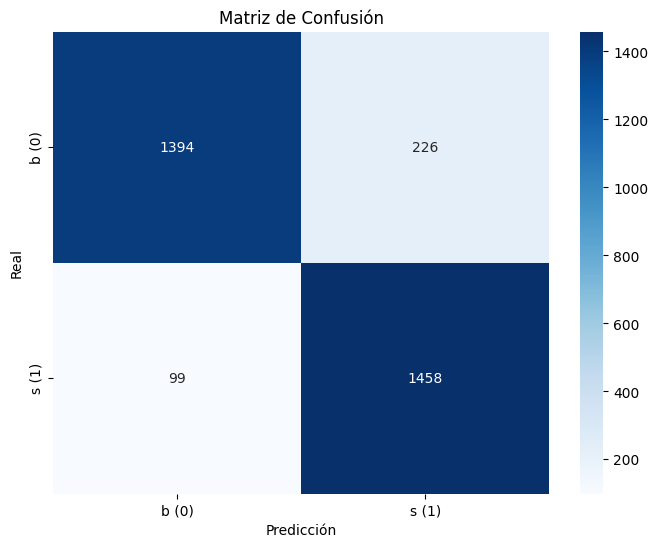


Observación: La matriz de confusión muestra 1394 verdaderos negativos, 226 falsos positivos, 99 falsos negativos y 1458 verdaderos positivos.


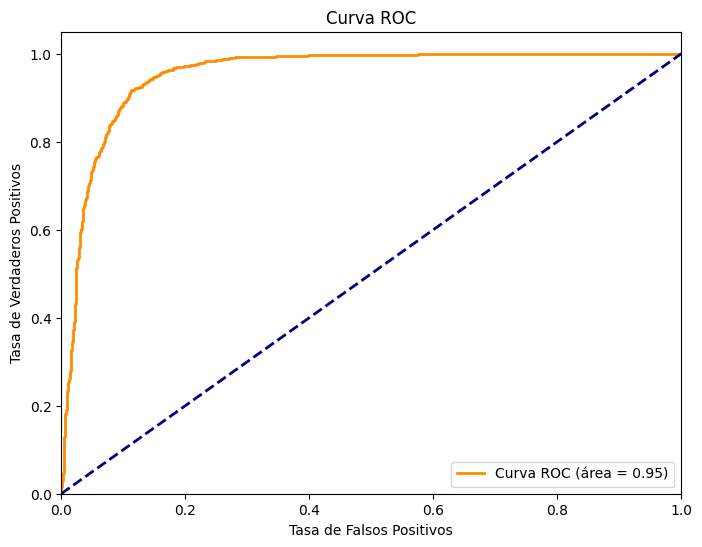


Observación: El área bajo la curva ROC (AUC) es de 0.95, lo que indica un buen rendimiento del modelo en la separación de clases.


In [ ]:
# Métricas de evaluación
print("\nMétricas de evaluación:")
print(classification_report(y_test, y_pred))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['b (0)', 's (1)'], # Mantener etiquetas para claridad
            yticklabels=['b (0)', 's (1)']) # Mantener etiquetas para claridad
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()
print(f"\nObservación: La matriz de confusión muestra {cm[0,0]} verdaderos negativos, {cm[0,1]} falsos positivos, {cm[1,0]} falsos negativos y {cm[1,1]} verdaderos positivos.")

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (área = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC')
plt.legend(loc="lower right")
plt.show()
print(f"\nObservación: El área bajo la curva ROC (AUC) es de {roc_auc:.2f}, lo que indica un buen rendimiento del modelo en la separación de clases.")

In [ ]:
results = X_test.copy()
results['Prediccion'] = y_test # Etiquetas verdaderas
results['Label'] = y_pred # Etiquetas predichas (0 o 1)
results['XGB'] = y_pred_proba # Probabilidad de ser clase 1
results['weight'] = w_test  # <-- añadir los pesos (corrección: se eliminó .values)
# Guardar resultados en un nuevo archivo CSV
results.to_csv('higgs_prediction_results.csv', index=False)
print('\nResultados con probabilidades de clasificación guardados en "higgs_prediction_results.csv"')


Resultados con probabilidades de clasificación guardados en "higgs_prediction_results.csv"


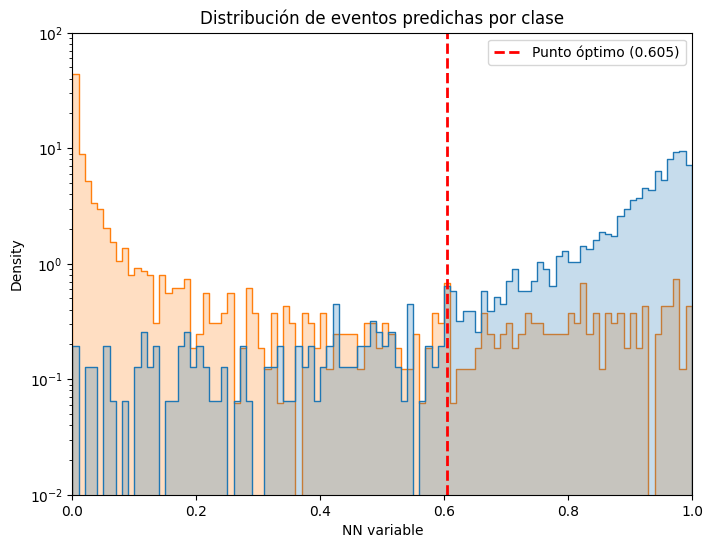


Observación: El umbral óptimo de probabilidad, calculado mediante la estadística J de Youden, es de 0.605. Este umbral maximiza la diferencia entre la tasa de verdaderos positivos y la tasa de falsos positivos.


In [ ]:
# Gráfica de distribución de probabilidades predichas
# Calcular el punto óptimo usando Youden's J statistic
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
youden_j = tpr - fpr
optimal_idx = np.argmax(youden_j)
optimal_threshold = thresholds[optimal_idx]

plt.figure(figsize=(8, 6))
sns.histplot(data={'NN variable': y_pred_proba.flatten(), 'Clase': y_test.replace({1: 's', 0: 'b'})}, # Mapear 1->'s', 0->'b' para el plot
             x='NN variable', hue='Clase', element='step', stat='density', common_norm=False, bins=100)

plt.title('Distribución de eventos predichas por clase')
plt.yscale('log')
plt.xlim(0, 1)          # Eje X de 0 a 1
plt.ylim(1e-2, 100)     # Eje Y de 10^-2 a 100

# Línea en el punto óptimo calculado
plt.axvline(x=optimal_threshold, color='red', linestyle='--', linewidth=2,
            label=f'Punto óptimo ({optimal_threshold:.3f})')

plt.legend()
plt.show()
print(f"\nObservación: El umbral óptimo de probabilidad, calculado mediante la estadística J de Youden, es de {optimal_threshold:.3f}. Este umbral maximiza la diferencia entre la tasa de verdaderos positivos y la tasa de falsos positivos.")

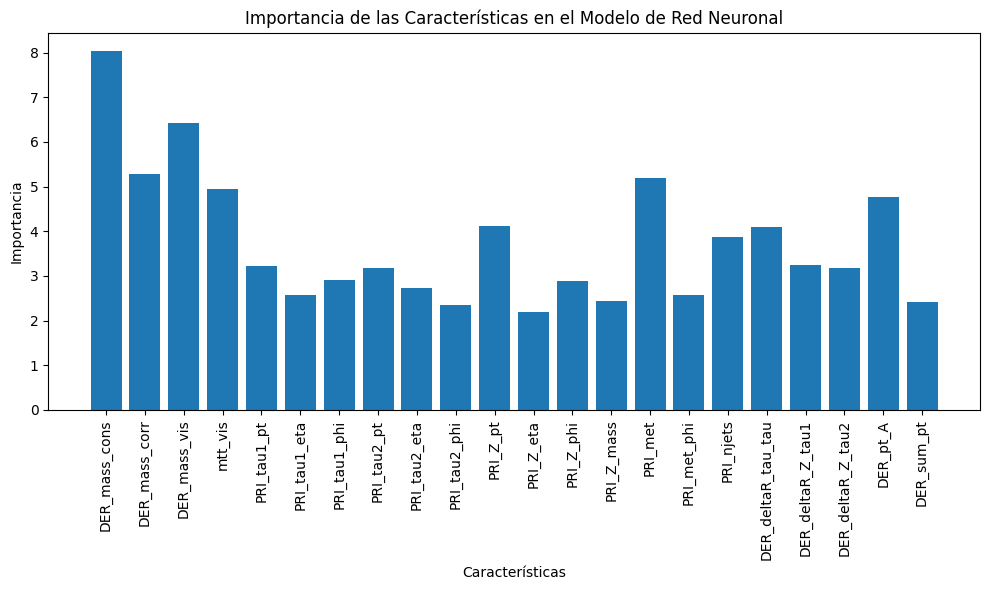


Observación: Las 3 características más importantes según el modelo de red neuronal son: DER_mass_cons, DER_mass_vis, DER_mass_corr.


In [ ]:
# Obtener los pesos de la primera capa del modelo
weights = mlp.coefs_[0] # Pesos de la primera capa

# Calcular la importancia de las características (suma de los valores absolutos de los pesos)
importance = np.sum(np.abs(weights), axis=1)

# Obtener los nombres de las características
feature_names = X.columns # Usar las columnas de X que se usaron para el entrenamiento

# Crear la gráfica de importancia
plt.figure(figsize=(10, 6))
plt.bar(range(len(feature_names)), importance)
plt.xticks(range(len(feature_names)), feature_names, rotation=90) # Rotar etiquetas para mejor visibilidad
plt.xlabel('Características')
plt.ylabel('Importancia')
plt.title('Importancia de las Características en el Modelo de Red Neuronal')
plt.tight_layout() # Ajustar el diseño para evitar que las etiquetas se corten
plt.show()

# Encontrar las características más importantes
sorted_importance_indices = np.argsort(importance)[::-1]
top_3_features = [feature_names[i] for i in sorted_importance_indices[:3]]
print(f"\nObservación: Las 3 características más importantes según el modelo de red neuronal son: {', '.join(top_3_features)}.")

Mejor umbral: 0.840  -> Significancia = 0.1663


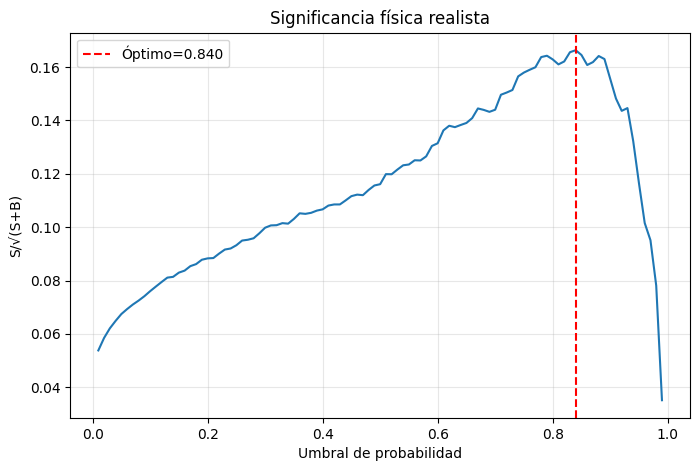


Observación: El umbral de probabilidad que maximiza la significancia (S/√(S+B)) es 0.840, con un valor de significancia de 0.1663. Este punto representa un buen equilibrio entre la señal y el fondo para la detección de eventos.


In [ ]:
# Cargar el CSV con pesos
df = pd.read_csv('higgs_prediction_results.csv')
# df debe tener: 'Prediccion' (etiqueta real), 'XGB' (probabilidad), 'weight'
y_true = df['Prediccion']
probs = df['XGB']
weights = df['weight']

# Función de significancia
def compute_significance(y_true, probs, weights, threshold):
    mask = probs > threshold
    S = weights[mask & (y_true == 1)].sum()
    B = weights[mask & (y_true == 0)].sum()
    if S + B == 0:
        return 0.0
    return S / np.sqrt(S + B)

# Barrido
thresholds = np.linspace(0.01, 0.99, 99)
sig_values = [compute_significance(y_true, probs, weights, t) for t in thresholds]

best_idx = np.argmax(sig_values)
best_thr = thresholds[best_idx]
best_sig = sig_values[best_idx]

print(f"Mejor umbral: {best_thr:.3f}  -> Significancia = {best_sig:.4f}")

plt.figure(figsize=(8,5))
plt.plot(thresholds, sig_values)
plt.axvline(best_thr, color='red', linestyle='--', label=f'Óptimo={best_thr:.3f}')
plt.xlabel('Umbral de probabilidad')
plt.ylabel('S/√(S+B)')
plt.legend()
plt.grid(alpha=0.3)
plt.title('Significancia física realista')
plt.show()
print(f"\nObservación: El umbral de probabilidad que maximiza la significancia (S/√(S+B)) es {best_thr:.3f}, con un valor de significancia de {best_sig:.4f}. Este punto representa un buen equilibrio entre la señal y el fondo para la detección de eventos.")

## Distribución de las 5 características más importantes

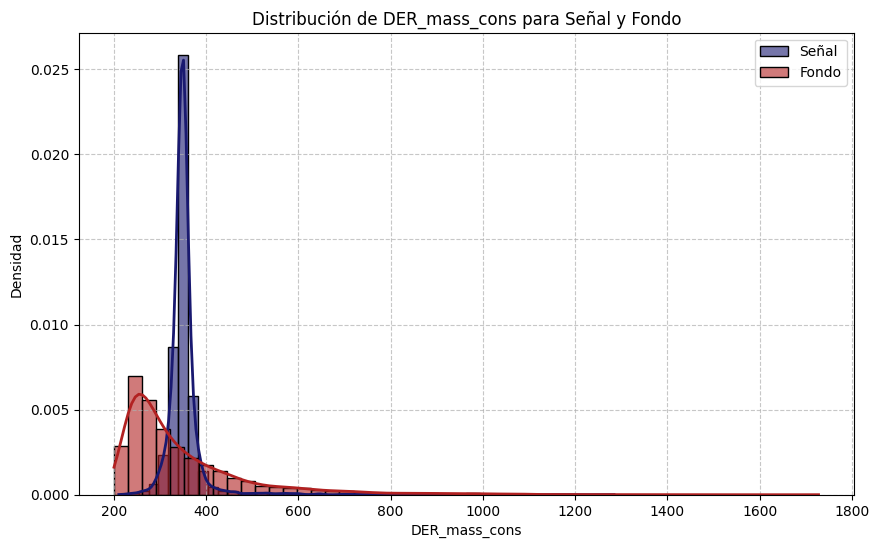


Observación: La característica 'DER_mass_cons' muestra diferencias en la distribución entre señal y fondo, lo que confirma su importancia en la discriminación.


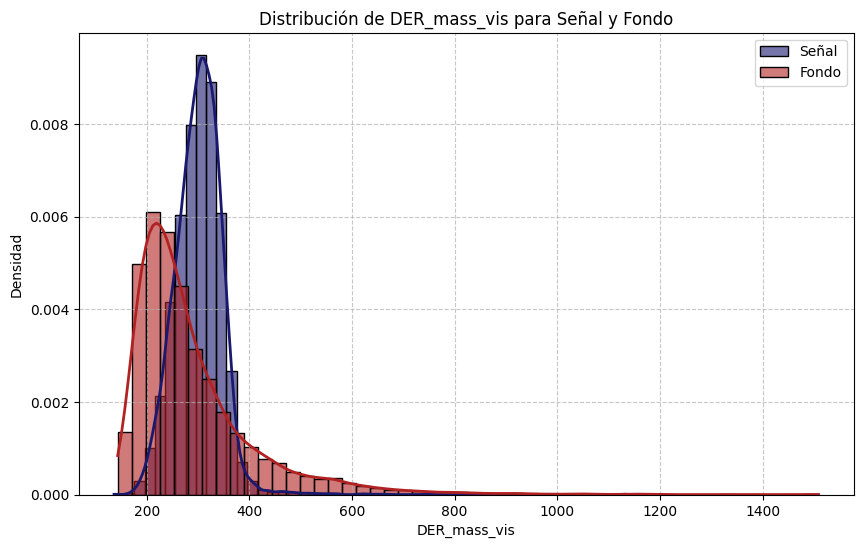


Observación: La característica 'DER_mass_vis' muestra diferencias en la distribución entre señal y fondo, lo que confirma su importancia en la discriminación.


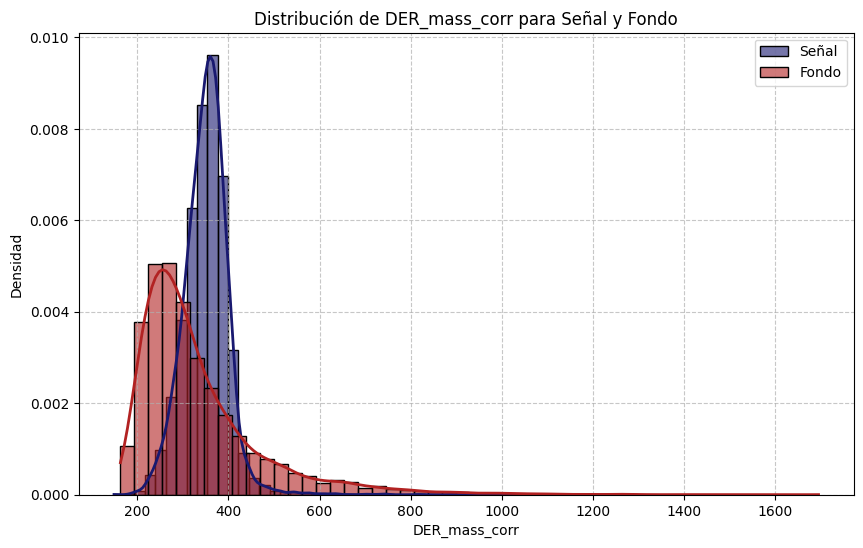


Observación: La característica 'DER_mass_corr' muestra diferencias en la distribución entre señal y fondo, lo que confirma su importancia en la discriminación.


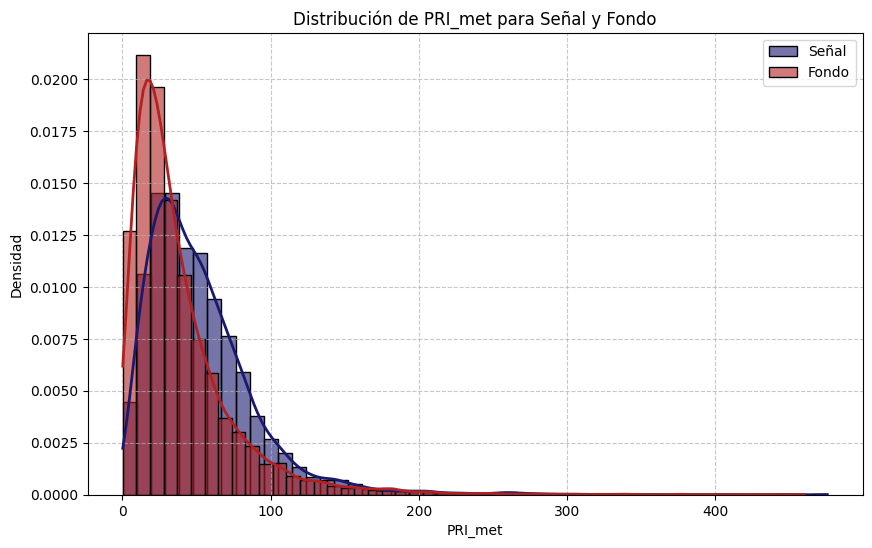


Observación: La característica 'PRI_met' muestra diferencias en la distribución entre señal y fondo, lo que confirma su importancia en la discriminación.


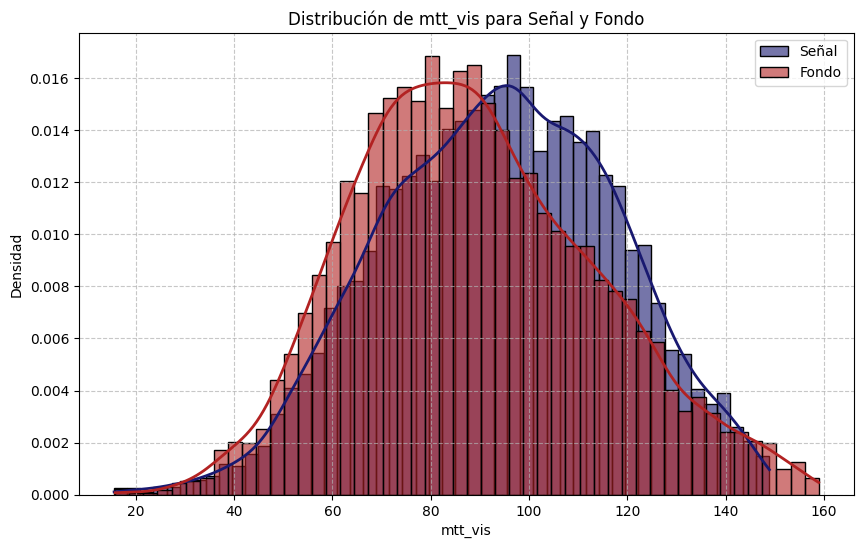


Observación: La característica 'mtt_vis' muestra diferencias en la distribución entre señal y fondo, lo que confirma su importancia en la discriminación.


In [ ]:
# Encontrar las 5 características más importantes
sorted_importance_indices = np.argsort(importance)[::-1]
top_5_features = [feature_names[i] for i in sorted_importance_indices[:5]]

# Crear histogramas para las 5 características más importantes
for feature in top_5_features:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=data[data.Label == 1], x=feature, bins=50, color='midnightblue', label='Señal', kde=True, stat='density', alpha=0.6, line_kws={'linewidth':2})
    sns.histplot(data=data[data.Label == 0], x=feature, bins=50, color='firebrick', label='Fondo', kde=True, stat='density', alpha=0.6, line_kws={'linewidth':2})
    plt.title(f'Distribución de {feature} para Señal y Fondo')
    plt.xlabel(feature)
    plt.ylabel('Densidad')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
    print(f"\nObservación: La característica '{feature}' muestra diferencias en la distribución entre señal y fondo, lo que confirma su importancia en la discriminación.")

## Resumen de Resultados Importantes

In [ ]:
print('--- Resumen de Resultados ---')

# Datos cargados
print(f"\n1. Tamaño de los datos cargados: {data.shape}")

# Eventos de señal y background
print(f"\n2. Número de eventos de señal: {len(data[data.Label == 1])}")
print(f"   Número de eventos de background: {len(data[data.Label == 0])}")
print(f"   Fracción de señal: {len(data[data.Label == 1])/(float)(len(data[data.Label == 1]) + len(data[data.Label == 0])):.4f}")

# Características altamente correlacionadas
if 'to_drop' in locals() and to_drop:
    print(f"\n3. Características con alta correlación (>0.95) a considerar eliminar: {to_drop}")
else:
    print("\n3. No se encontraron características con correlación mayor a 0.95 en la señal.")

# Mejores hiperparámetros de Optuna
if 'best_params' in locals():
    print("\n4. Mejores hiperparámetros encontrados por Optuna para MLP:")
    for key, value in best_params.items():
        print(f"   - {key}: {value}")

# Rendimiento del modelo (AUC-ROC)
if 'roc_auc' in locals():
    print(f"\n5. Área bajo la curva ROC (AUC) del modelo MLP: {roc_auc:.4f}")

# Umbral óptimo de Youden
if 'optimal_threshold' in locals():
    print(f"\n6. Umbral óptimo de probabilidad (Youden's J): {optimal_threshold:.3f}")

# Características más importantes
if 'top_3_features' in locals():
    print(f"\n7. Las 3 características más importantes según el modelo: {', '.join(top_3_features)}")

# Umbral de significancia física
if 'best_thr' in locals() and 'best_sig' in locals():
    print(f"\n8. Umbral de probabilidad que maximiza la significancia (S/\u221a(S+B)): {best_thr:.3f} (Significancia: {best_sig:.4f})")

# Las 5 características principales utilizadas para histogramas
if 'top_5_features' in locals():
    print(f"\n9. Las 5 características principales visualizadas en histogramas: {', '.join(top_5_features)}")

print('\n--- Fin del Resumen ---')

--- Resumen de Resultados ---

1. Tamaño de los datos cargados: (15882, 25)

2. Número de eventos de señal: 7785
   Número de eventos de background: 8097
   Fracción de señal: 0.4902

3. Características con alta correlación (>0.95) a considerar eliminar: ['DER_mass_vis']

4. Mejores hiperparámetros encontrados por Optuna para MLP:
   - hidden_layer_sizes: (30, 15)
   - alpha: 0.03432161199982761
   - learning_rate_init: 0.0009363600019624182
   - batch_size: 32
   - max_iter: 350

5. Área bajo la curva ROC (AUC) del modelo MLP: 0.9548

6. Umbral óptimo de probabilidad (Youden's J): 0.605

7. Las 3 características más importantes según el modelo: DER_mass_cons, DER_mass_vis, DER_mass_corr

8. Umbral de probabilidad que maximiza la significancia (S/√(S+B)): 0.840 (Significancia: 0.1663)

9. Las 5 características principales visualizadas en histogramas: DER_mass_cons, DER_mass_vis, DER_mass_corr, PRI_met, mtt_vis

--- Fin del Resumen ---
